# Iteraciones de Modelado para crear Features
(Datos Originales NFL)
En este notebook iremos explorando qué features se pueden crear con el propósito de mejorar el desempeño del modelo.

## Requisitos para extraer datos

In [1]:
#import gspread

#from google.colab import auth
#from google.colab import drive
#from google.auth import default
#from functools import reduce

#auth.authenticate_user()
#drive.mount('/content/gdrive')
#creds, _ = default()
#gc = gspread.authorize(creds)

# path
#%cd /content/gdrive/MyDrive/'NFL Big Data Bowl 2025'/

## Imports

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import pickle
import scipy.spatial as ss
import seaborn as sns
import shap
import warnings

from functools import reduce
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale, LabelEncoder
from xgboost import XGBClassifier

from feature_func import (
    get_path, 
    add_prefix_to_dataframe,
    add_player_info_to_tracking,
    influence_function_actual_pos, 
    get_metrics_distance_between_team_players,
    compute_individual_players_info_for_tracking_df,
    encode_position_tracking_df_w_player_info,
    get_general_and_team_info,
    general_vs_team_distance_metrics_info,
    most_influence_info,
)

from graph_feature import *
# get_graph_with_nodes_attrs

Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.


## Configuration

In [3]:
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 5000)

## Constants

In [4]:
nb_tracks = 8
SECONDS = 0.5
RANDOM_SEED = 42

## Paths


In [5]:
BASE_PATH = os.path.join(os.getcwd(), '../')
DATA_PATH = get_path(BASE_PATH, "data")
ORIGINAL_DATA_PATH = get_path(DATA_PATH, "original")
GAMES_PATH = get_path(ORIGINAL_DATA_PATH, "games.csv")
PLAYERS_PATH = get_path(ORIGINAL_DATA_PATH, "players.csv")
PLAYS_PATH = get_path(ORIGINAL_DATA_PATH, "plays.csv")
#PLAYER_PLAY_PATH = get_path(ORIGINAL_DATA_PATH, "player_play.csv")
TRACKING_PATH = get_path(ORIGINAL_DATA_PATH, "tracking")
POSITION_DICT_PATH = get_path(ORIGINAL_DATA_PATH, "position_dictionary.csv")

## Read Data

In [6]:
games_df = pd.read_csv(GAMES_PATH)
players_df = pd.read_csv(PLAYERS_PATH)
play_df = pd.read_csv(PLAYS_PATH)
position_dictionary_df = pd.read_csv(POSITION_DICT_PATH, index_col=0)
tracking_df = pd.concat([
    pd.read_csv(get_path(TRACKING_PATH, f))for f in os.listdir(TRACKING_PATH)[: nb_tracks]
])

## Slight data modifications

In [7]:
# Corregir algunos eventos de tracking df. 
tracking_df.loc[tracking_df.event == 'autoevent_ballsnap', 'event'] = 'ball_snap'
tracking_df.loc[tracking_df.event == 'autoevent_passforward', 'event'] = 'pass_forward'
tracking_df.loc[tracking_df.event == 'autoevent_passinterrupted', 'event'] = 'pass_outcome_incomplete'

In [8]:
# Agregar info a players df respecto al diccionario construido. 
players_df['position_group'] = players_df.position.map(position_dictionary_df.T.to_dict()).apply(lambda x: x['group'])
players_df['position_subgroup'] = players_df.position.map(position_dictionary_df.T.to_dict()).apply(lambda x: x['subgroup'])

## Feature computation

### After snap
This will define the response variable and the index corresponding to the sample.

In [9]:
# Get everything after snap.
after_snap_tracking_df = tracking_df[tracking_df.frameType == 'AFTER_SNAP']

# Now we keep the relevant events. 
after_snap_events = after_snap_tracking_df[after_snap_tracking_df.event.notna()]

# Of the relevant events, we can make a list for each game_id, and play_id
all_events_reduced = after_snap_events[
    after_snap_events.club=='football' # Reduce the possibilities. 
].groupby(
    ['gameId', 'playId', 'frameType']
).agg(
    {'event': lambda x: list(x)}
).reset_index()

# We can now filter the game and plays that have (pass_forward or pass_arrived) with the 
# corresponding pass_outcome_caught. 
plays_with_response_variable = all_events_reduced[
    all_events_reduced.event.apply(
        lambda x: (
            ('pass_forward' in x or 'pass_arrived' in x) and 
            ("pass_outcome_caught" in x or "pass_outcome_touchdown" in x)
        )
    )
].drop(['frameType', 'event'], axis=1)

plays_with_response_variable['is_response_variable_candidate'] = 1

In [10]:
#### Response variable and game_id plays_id that will be defined as the core of the proyect. 
cols = ['gameId', 'playId', 'frameId', 'time', 'playDirection', 'event']
# Selecting only the events (including those where nothing happens).
event_occurence = after_snap_tracking_df.drop_duplicates(['gameId', 'playId', 'frameId'])[cols]

# Where there exists no event, lets fill it with none.
event_occurence = event_occurence.fillna('None')
event_occurence.time = pd.to_datetime(event_occurence.time, format='ISO8601')

# Lets get a future event:
event_occurence['current_time'] = event_occurence.time - pd.Timedelta(seconds=SECONDS)
event_occurence['future_event'] = event_occurence.event
future_event_occurence = event_occurence[
    ['gameId', 'playId', 'frameId', 'current_time', 'future_event']
]
event_occurence = event_occurence.drop(['current_time', 'future_event'], axis=1)
event_occurence = event_occurence.merge(
    future_event_occurence[['current_time', 'future_event', 'playId', 'gameId']],
    left_on=['time', 'playId', 'gameId'],
    right_on=['current_time', 'playId', 'gameId'],
    how='left'
)
event_occurence['is_pass_forward'] = (event_occurence.future_event == 'pass_forward').astype('int')
event_occurence = event_occurence.merge(plays_with_response_variable, on=['gameId', 'playId'], how='left')

event_occurence.loc[
    (event_occurence.is_pass_forward==1) & (event_occurence.is_response_variable_candidate==1), 'target'
] = 1
event_occurence['target'] = event_occurence['target'].fillna(0)

### Core dataset

In [11]:
# Selecting only the most important envents events.
relevant_event_occurence = event_occurence[event_occurence.future_event!='None'].dropna()
# Selecting some of the non-important envents events.
non_relevant_event_occurence = event_occurence[event_occurence.future_event=='None'].sample(
    random_state=RANDOM_SEED, n=relevant_event_occurence.shape[0]//3
)
# Merge all information in one dataframe. This will be the core of the proyect.
sample_event_occurence = pd.concat([relevant_event_occurence, non_relevant_event_occurence])

In [12]:
# Shuffle sample event occurence
reorgainzed_sample_event_occurence = sample_event_occurence.sample(frac=1, random_state=RANDOM_SEED)

In [13]:
current_event_stuff = reorgainzed_sample_event_occurence.set_index(['gameId', 'playId', 'frameId'])[['playDirection', 'target']]
current_event_stuff['playDirection'] = current_event_stuff.playDirection.map({'right': 0, 'left': 1})

### play_df reduced
Features at play level

In [14]:
reduced_play_df = reorgainzed_sample_event_occurence[['gameId', 'playId', 'frameId']].merge(play_df, on=['gameId', 'playId'], how='left')
reduced_play_df = reduced_play_df.merge(games_df[['gameId', 'homeTeamAbbr', 'visitorTeamAbbr']], on='gameId', how='inner')

reduced_play_df['team_deffinition'] = reduced_play_df.apply(lambda x: {x.possessionTeam: 1, x.defensiveTeam: -1}, axis=1)
reduced_play_df['gameClock_time'] = reduced_play_df.gameClock.str.split(':').apply(lambda x: int(x[0])*60 + int(x[1]))

home_posseses = reduced_play_df['homeTeamAbbr'] == reduced_play_df['possessionTeam']
visit_posseses = reduced_play_df['visitorTeamAbbr'] == reduced_play_df['possessionTeam']

home_deffends = reduced_play_df['homeTeamAbbr'] == reduced_play_df['defensiveTeam']
visit_deffends = reduced_play_df['visitorTeamAbbr'] == reduced_play_df['defensiveTeam']

reduced_play_df.loc[home_posseses, 'preSnapPossessionScore'] = reduced_play_df[home_posseses].preSnapHomeScore
reduced_play_df.loc[visit_posseses, 'preSnapPossessionScore'] = reduced_play_df[visit_posseses].preSnapVisitorScore

reduced_play_df.loc[home_deffends, 'preSnapDefensiveScore'] = reduced_play_df[home_deffends].preSnapHomeScore
reduced_play_df.loc[visit_deffends, 'preSnapDefensiveScore'] = reduced_play_df[visit_deffends].preSnapVisitorScore

reduced_play_df.loc[home_posseses, 'preSnapPossessionTeamWinProbability'] = reduced_play_df[home_posseses].preSnapHomeTeamWinProbability
reduced_play_df.loc[visit_posseses, 'preSnapPossessionTeamWinProbability'] = reduced_play_df[visit_posseses].preSnapVisitorTeamWinProbability

reduced_play_df.loc[home_deffends, 'preSnapDefensiveTeamWinProbability'] = reduced_play_df[home_deffends].preSnapHomeTeamWinProbability
reduced_play_df.loc[visit_deffends, 'preSnapDefensiveTeamWinProbability'] = reduced_play_df[visit_deffends].preSnapVisitorTeamWinProbability

reduced_play_df['preSnapScore_difference'] = reduced_play_df['preSnapPossessionScore'] - reduced_play_df['preSnapDefensiveScore']
reduced_play_df['preSnapTeamWinProbability_difference'] = reduced_play_df['preSnapPossessionTeamWinProbability'] - reduced_play_df['preSnapDefensiveTeamWinProbability']

reduced_play_df['receiverAlignment_0'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[0]).astype('int')
reduced_play_df['receiverAlignment_1'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[1]).astype('int')

play_features_columns = [
    'gameId', # Id column
    'playId', # Id column
    'frameId', # Id column
    'quarter', 
    'down', 
    'yardsToGo', 
    'yardlineNumber',
    'absoluteYardlineNumber',
    'preSnapScore_difference', 
    'preSnapTeamWinProbability_difference',
    'expectedPoints',
    'playClockAtSnap',
    'receiverAlignment_0',
    'receiverAlignment_1',
    'gameClock_time',
    'team_deffinition', 
]
reduced_play_df = reduced_play_df[play_features_columns].set_index(['gameId', 'playId', 'frameId'])

In [15]:
# IMPORTANT: At this point we have already relevant information on relevant events, and some where nothing happened, instead of focusing in all the tracking ids.

# Now we can simplify what happened in the tracking_df, with the new indexes, creating a reduced_tracking_df.
#tracking_df['game_play_frame_id'] = tracking_df.gameId.astype('str') + '_' + tracking_df.playId.astype('str') + '_' + tracking_df.frameId.astype('str')
reduced_tracking_df = tracking_df.merge(
    reorgainzed_sample_event_occurence[
        ['gameId', 'playId', 'frameId', 'target']
    ],
    on=['gameId', 'playId', 'frameId'], 
    how='right',
)
#reduced_tracking_df['game_play'] = reduced_tracking_df.gameId.astype('str') + '_' + reduced_tracking_df.playId.astype('str')


In [16]:
reduced_tracking_w_player_info_df = add_player_info_to_tracking(reduced_tracking_df, players_df, reduced_play_df)

In [17]:
reduced_tracking_w_player_info_df, lb_player_position, lb_player_position_group, lb_player_position_subgroup = encode_position_tracking_df_w_player_info(
    reduced_tracking_w_player_info_df, train=True, encoders=None
)
position_encoders = lb_player_position, lb_player_position_group, lb_player_position_subgroup

reduced_tracking_w_player_info_df = compute_individual_players_info_for_tracking_df(reduced_tracking_w_player_info_df)

### Before Snap Computations

Before snap features are gameId, playId features not considering the corresponding frameId 
since we are getting all the information before the snap. 

Some feature ideas might be:
- Graph at line_set and graph at the ball_snap moment, and get the corresponding differences.
- Mechanical features computed and get the difference as well.

In [18]:
unique_sample_event_occurence = sample_event_occurence[['gameId', 'playId']].drop_duplicates()

In [19]:
before_snap_tracking_df = tracking_df[tracking_df.frameType != 'AFTER_SNAP']

#### Event list before snap

In [20]:
event_list_before_snap = before_snap_tracking_df[
    before_snap_tracking_df.club == 'football'
].sort_values(['gameId', 'playId', 'frameId']).groupby(
    ['gameId', 'playId']
).event.apply(
    lambda x: list(x.dropna())
)
event_list_before_snap = event_list_before_snap.reset_index().merge(
    unique_sample_event_occurence, on=['gameId', 'playId'], how='right'
).set_index(['gameId', 'playId'])

ERROR! Session/line number was not unique in database. History logging moved to new session 90


In [21]:
presnap_event_encoder = LabelEncoder()
presnap_event_encoder.fit(event_list_before_snap.event.astype('str').unique())
event_list_before_snap['encoded_event'] = presnap_event_encoder.transform(event_list_before_snap.event.astype('str'))

In [22]:
# Reslut df:
# event_list_before_snap

In [23]:
before_snap_ls_bs = before_snap_tracking_df[
    before_snap_tracking_df.event.isin(['line_set', 'ball_snap'])
]
# There might be some duplicates, with this we remove them. 
before_snap_ls_bs = before_snap_ls_bs.groupby(
    ['gameId', 'playId', 'event', 'displayName']
).first().reset_index()

before_snap_ls = before_snap_ls_bs[
    before_snap_ls_bs.event == 'line_set'
].merge(
    unique_sample_event_occurence, on=['gameId', 'playId'],
    how='inner'
)

before_snap_bs = before_snap_ls_bs[
    before_snap_ls_bs.event == 'ball_snap'
].merge(
    unique_sample_event_occurence, on=['gameId', 'playId'],
    how='inner'
)

In [24]:
before_snap_ls_w_player_info = add_player_info_to_tracking(before_snap_ls, players_df, reduced_play_df)
before_snap_ls_w_player_info = encode_position_tracking_df_w_player_info(before_snap_ls_w_player_info, encoders=position_encoders)
before_snap_ls_w_player_info = compute_individual_players_info_for_tracking_df(before_snap_ls_w_player_info)

In [25]:
before_snap_bs_w_player_info = add_player_info_to_tracking(before_snap_bs, players_df, reduced_play_df)
before_snap_bs_w_player_info = encode_position_tracking_df_w_player_info(before_snap_bs_w_player_info, encoders=position_encoders)
before_snap_bs_w_player_info = compute_individual_players_info_for_tracking_df(before_snap_bs_w_player_info)

In [26]:
# At moment, lineset and ball snap general and team info.
general_reduced_tracking_w_player_info_df = get_general_and_team_info(reduced_tracking_w_player_info_df)

line_set_general_reduced_tracking_w_player_info_df = add_prefix_to_dataframe(
    df=get_general_and_team_info(before_snap_ls_w_player_info), 
    prefix="line_set"
).reset_index(drop=True, level=-1)

ball_snap_general_reduced_tracking_w_player_info_df = add_prefix_to_dataframe(
    df=get_general_and_team_info(before_snap_bs_w_player_info),
    prefix="ball_snap"
).reset_index(drop=True, level=-1)

In [27]:
# relevant dfs:
#general_reduced_tracking_w_player_info_df, line_set_general_reduced_tracking_w_player_info_df, ball_snap_general_reduced_tracking_w_player_info_df

In [28]:
most_influence_info_df = most_influence_info(reduced_tracking_w_player_info_df)

line_set_most_influence_info = add_prefix_to_dataframe(
    df=most_influence_info(before_snap_ls_w_player_info), 
    prefix="line_set"
).reset_index(drop=True, level=-1)

ball_snap_most_influence_info = add_prefix_to_dataframe(
    df=most_influence_info(before_snap_bs_w_player_info),
    prefix="ball_snap"
).reset_index(drop=True, level=-1)

In [29]:
# relevant dfs:
# most_influence_info_df, line_set_most_influence_info, ball_snap_most_influence_info

In [30]:
general_vs_team_distance_metrics_df = general_vs_team_distance_metrics_info(
    reduced_tracking_w_player_info_df
)

ball_snap_general_vs_team_distance_metrics_df = add_prefix_to_dataframe(
    df=general_vs_team_distance_metrics_info(before_snap_bs_w_player_info), 
    prefix="ball_snap"
).reset_index(drop=True, level=-1)

line_set_general_vs_team_distance_metrics_df = add_prefix_to_dataframe(
    df=general_vs_team_distance_metrics_info(before_snap_ls_w_player_info), 
    prefix="line_set"
).reset_index(drop=True, level=-1)

In [31]:
# relevant dfs
# general_vs_team_distance_metrics_df, ball_snap_general_vs_team_distance_metrics_df, line_set_general_vs_team_distance_metrics_df

In [32]:
# Metrics of the ball position relative to the teams can also be computed: 
# These features are only worth for in time metrics, not presnap. 
football_info_df = reduced_tracking_w_player_info_df[reduced_tracking_w_player_info_df.club == 'football'].set_index(['gameId', 'playId', 'frameId'])
not_futball_columns = [
    'nflId', 
    'dir', 
    'event',
    'weight',
    'encoded_position',
    'o',
    'action', 
    'ke',
    'fx', 
    'fy',
    'f',
    'px',
    'py',
    'work',
    'club',
    #'team_deffinition', 
    #'team_redeffinition', 
    'encoded_position_group', 
    'encoded_position_subgroup',
    'current_position_influence', 
]
football_info_df.drop(not_futball_columns, axis=1, inplace=True)
football_info_df['distance_general'] = (
    (general_reduced_tracking_w_player_info_df.x__general - football_info_df.x) ** 2 + 
    (general_reduced_tracking_w_player_info_df.y__general - football_info_df.y) ** 2
)
football_info_df['distance_possesion_team'] = (
    (football_info_df.x - general_reduced_tracking_w_player_info_df.x__possesion) ** 2 + 
    (football_info_df.y - general_reduced_tracking_w_player_info_df.y__possesion) ** 2
)
football_info_df['distance_defensive_team'] = (
    (football_info_df.x - general_reduced_tracking_w_player_info_df.x__defensive) ** 2 + 
    (football_info_df.y - general_reduced_tracking_w_player_info_df.y__defensive) ** 2
)

all_players_reduced_tracking_positions = reduced_tracking_w_player_info_df[
    reduced_tracking_w_player_info_df.club != 'football'
].set_index(['gameId', 'playId', 'frameId'])[['x', 'y', 'encoded_position', 'club']]

all_players_reduced_tracking_positions['distance_to_football'] = list(
    (football_info_df.x-all_players_reduced_tracking_positions.x)**2 + 
    (football_info_df.y-all_players_reduced_tracking_positions.y)**2
)

all_players_reduced_tracking_positions.reset_index(inplace=True)

all_players_reduced_tracking_positions = all_players_reduced_tracking_positions.merge(
    reduced_play_df.reset_index()[['gameId', 'playId', 'frameId', 'team_deffinition']], on=['gameId', 'playId', 'frameId'], how='left'
)


all_players_reduced_tracking_positions['team_redeffinition'] = all_players_reduced_tracking_positions.apply(
    lambda row: row.team_deffinition[row.club], axis=1
)

min_distances_to_ball = all_players_reduced_tracking_positions.sort_values(
    ['gameId', 'playId', 'frameId', 'distance_to_football']
).drop_duplicates(
    ['gameId', 'playId', 'frameId', 'team_redeffinition'], keep='first'
)

min_distances_to_ball_defensive = min_distances_to_ball[
    min_distances_to_ball.team_redeffinition==-1
].set_index(['gameId', 'playId', 'frameId'])[['encoded_position', 'distance_to_football']]

min_distances_to_ball_possesion = min_distances_to_ball[
    min_distances_to_ball.team_redeffinition==1
].set_index(['gameId', 'playId', 'frameId'])[['encoded_position', 'distance_to_football']]

min_distances_to_ball_defensive.rename(
    columns={col: f'min_{col}_defensive' for col in min_distances_to_ball_defensive.columns}, inplace=True
)
min_distances_to_ball_possesion.rename(
    columns={col: f'min_{col}_possesion' for col in min_distances_to_ball_possesion.columns}, inplace=True
)

football_info_df.rename(columns={col:f'football_{col}' for col in football_info_df.columns}, inplace=True)
football_info_df.drop(['football_team_deffinition', 'football_team_redeffinition'], axis=1, inplace=True)

In [33]:
# Football dfs results
#football_info_df, min_distances_to_ball_possesion,  min_distances_to_ball_defensive

In [34]:
# Remove the line players 
reduced_tracking_w_player_info_no_line_df = reduced_tracking_w_player_info_df[
    ~np.isin(lb_player_position_subgroup.inverse_transform(reduced_tracking_w_player_info_df.encoded_position_subgroup), ['OL', 'DL'])
]

In [35]:
# Graph creation

In [36]:
graphs_whole_team = reduced_tracking_w_player_info_df.groupby(
    ['gameId', 'playId', 'frameId']
).apply(
    get_graph_with_nodes_attrs, no_negatives=True
)

In [37]:
graphs_noline = reduced_tracking_w_player_info_no_line_df.groupby(
    ['gameId', 'playId', 'frameId']
).apply(
    get_graph_with_nodes_attrs, no_negatives=True
)

In [38]:
graphs_bs = before_snap_bs_w_player_info.groupby(
    ['gameId', 'playId', 'frameId']
).apply(
    get_graph_with_nodes_attrs, no_negatives=True
)

graphs_ls = before_snap_ls_w_player_info.groupby(
    ['gameId', 'playId', 'frameId']
).apply(
    get_graph_with_nodes_attrs, no_negatives=True
)

In [39]:
# Graph embeddings

In [40]:
graphs_whole_team_feather_embeddings = graphs_whole_team.apply(get_feathergraph_embedding)

In [41]:
graphs_bs_feather_embeddings = graphs_bs.apply(get_feathergraph_embedding)

In [42]:
graphs_ls_feather_embeddings = graphs_ls.apply(get_feathergraph_embedding)

In [43]:
graphs_whole_team_feather_embeddings_df = pd.DataFrame(
    np.concatenate(graphs_whole_team_feather_embeddings.to_numpy()).reshape(graphs_whole_team_feather_embeddings.shape[0], len(graphs_whole_team_feather_embeddings.iloc[0])),
    index=graphs_whole_team_feather_embeddings.index,
    columns=[f'feather_embeddings_{i}' for i in range(len(graphs_whole_team_feather_embeddings.iloc[0]))],
)

In [44]:
graphs_bs_feather_embeddings_df = pd.DataFrame(
    np.concatenate(graphs_bs_feather_embeddings.to_numpy()).reshape(graphs_bs_feather_embeddings.shape[0], len(graphs_bs_feather_embeddings.iloc[0])),
    index=graphs_bs_feather_embeddings.index,
    columns=[f'feather_embeddings_{i}' for i in range(len(graphs_bs_feather_embeddings.iloc[0]))],
).reset_index(drop=True, level=-1)

graphs_ls_feather_embeddings_df = pd.DataFrame(
    np.concatenate(graphs_ls_feather_embeddings.to_numpy()).reshape(graphs_ls_feather_embeddings.shape[0], len(graphs_ls_feather_embeddings.iloc[0])),
    index=graphs_ls_feather_embeddings.index,
    columns=[f'feather_embeddings_{i}' for i in range(len(graphs_ls_feather_embeddings.iloc[0]))],
).reset_index(drop=True, level=-1)

graphs_change_bs_ls_feather_embeddings_df = graphs_bs_feather_embeddings_df - graphs_ls_feather_embeddings_df

In [45]:
from sklearn.decomposition import PCA
pca_model = PCA(n_components=1000)
pca_model.fit(graphs_whole_team_feather_embeddings_df.fillna(0))
real_n_components = (abs(np.gradient(np.log(pca_model.explained_variance_))) > 0.1).sum()
pca_model = PCA(n_components=real_n_components*2)
pca_model.fit(graphs_whole_team_feather_embeddings_df.fillna(0))

graphs_whole_team_feather_embeddings_df_reduced = pd.DataFrame(
    pca_model.transform(graphs_whole_team_feather_embeddings_df.fillna(0)),
    index=graphs_whole_team_feather_embeddings_df.index,
    columns = [f'whole_team_feather_embeeding_reduced_{col}' for col in range(pca_model.n_components)]
)

In [46]:


from sklearn.decomposition import PCA
pca_model2 = PCA(n_components=1000)
pca_model2.fit(graphs_change_bs_ls_feather_embeddings_df.fillna(0))
real_n_components2 = (abs(np.gradient(np.log(pca_model2.explained_variance_))) > 0.1).sum()
pca_model2 = PCA(n_components=real_n_components2*2)
pca_model2.fit(graphs_change_bs_ls_feather_embeddings_df.fillna(0))

graphs_change_bs_ls_feather_embeddings_df_reduced = pd.DataFrame(
    pca_model2.transform(graphs_change_bs_ls_feather_embeddings_df.fillna(0)),
    index=graphs_change_bs_ls_feather_embeddings_df.index,
    columns = [f'change_bs_ls_feather_embeeding_reduced_{col}' for col in range(pca_model2.n_components)]
)

In [47]:
no_line_additional_features = graphs_noline.apply(compute_graph_structure_features)

no_line_additional_feather_embeddings = no_line_additional_features.apply(get_feathergraph_embedding)

graphs_noline_additional_feather_embeddings_df = pd.DataFrame(
    np.concatenate(no_line_additional_feather_embeddings.to_numpy()).reshape(no_line_additional_feather_embeddings.shape[0], len(no_line_additional_feather_embeddings.iloc[0])),
    index=no_line_additional_feather_embeddings.index,
    columns=[f'feather_embeddings_{i}' for i in range(len(no_line_additional_feather_embeddings.iloc[0]))],
)

pca_model3 = PCA(n_components=1000)
pca_model3.fit(graphs_noline_additional_feather_embeddings_df.fillna(0))
real_n_components3 = (abs(np.gradient(np.log(pca_model2.explained_variance_))) > 0.1).sum()
pca_model3 = PCA(n_components=real_n_components3*2)
pca_model3.fit(graphs_noline_additional_feather_embeddings_df.fillna(0))

graphs_noline_additional_feather_embeddings_df_reduced = pd.DataFrame(
    pca_model3.transform(graphs_noline_additional_feather_embeddings_df.fillna(0)),
    index=graphs_noline_additional_feather_embeddings_df.index,
    columns = [f'no_line_feather_embeeding_reduced_{col}' for col in range(pca_model3.n_components)]
)


KeyboardInterrupt



### Feature joining

In [48]:
# result_df_list = [
#     current_event_stuff, # Contains response var
#     team_reduced_tracking_w_player_info_df_difference,
#     general_reduced_tracking_w_player_info_df,
#     #min_distances_to_ball_defensive,
#     #min_distances_to_ball_possesion,
#     football_info_df,
#     general_vs_team_distance_metrics,
#     #fgsd_embeddings_df,
#     #adjacent_embeddings_df,
#     most_influence_defensive, 
#     most_influence_possesion,
#     feather_embeddings_df,
#     #graph_features,
# ]
# all_features = reduce(lambda left, right: pd.merge(left,right, left_index=True, right_index=True, how='left'), result_df_list)

In [126]:
#general_minus_lineset = general_reduced_tracking_w_player_info_df - line_set_general_reduced_tracking_w_player_info_df.rename(columns={col: col.replace('line_set_', '') for col in line_set_general_reduced_tracking_w_player_info_df.columns})
#general_minus_lineset = general_minus_lineset.rename(columns={col: f'general_minus_lineset__{col}' for col in general_minus_lineset.columns})


In [127]:
#general_miuns_ballsnap = general_reduced_tracking_w_player_info_df - ball_snap_general_reduced_tracking_w_player_info_df.rename(columns={col: col.replace('ball_snap_', '') for col in ball_snap_general_reduced_tracking_w_player_info_df.columns})
#general_miuns_ballsnap = general_miuns_ballsnap.rename(columns={col: f'general_miuns_ballsnap__{col}' for col in general_miuns_ballsnap.columns})


In [ ]:
general_reduced_tracking_w_player_info_df - line_set_general_reduced_tracking_w_player_info_df.rename(columns={col: col.replace('line_set_', '') for col in line_set_general_reduced_tracking_w_player_info_df.columns})

In [168]:
results_df_list = [
    # Initial play context
    reduced_play_df.drop('team_deffinition', axis=1),
    # General tracking information
    general_reduced_tracking_w_player_info_df,
    #line_set_general_reduced_tracking_w_player_info_df,
    #ball_snap_general_reduced_tracking_w_player_info_df,
    # Influence information
    most_influence_info_df,
    #line_set_most_influence_info,
    #ball_snap_most_influence_info,
    # Team and general distance metrics
    general_vs_team_distance_metrics_df, 
    #line_set_general_vs_team_distance_metrics_df,
    #ball_snap_general_vs_team_distance_metrics_df, 
    # Ball features without bs and ls dfs:
    football_info_df, 
    min_distances_to_ball_possesion,  
    min_distances_to_ball_defensive,
    
    # presnap events: 
    event_list_before_snap[['encoded_event']],

    # target and direction
    current_event_stuff,

    # Graph features
    #graphs_whole_team_feather_embeddings_df
    graphs_whole_team_feather_embeddings_df_reduced,
    #graphs_noline_additional_feather_embeddings_df
    #graphs_noline_additional_feather_embeddings_df_reduced,
    #graphs_change_bs_ls_feather_embeddings_df_reduced,
]

all_features = reduce(lambda left, right: pd.merge(left,right, left_index=True, right_index=True, how='left'), results_df_list)
#general_reduced_tracking_w_player_info_df, most_influence_info_df

In [169]:
#all_features.to_csv('../data/final/all_features.csv')

## Model preparation

In [170]:
X, y = all_features.drop('target', axis=1), all_features.target

### Train test split

In [171]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.5, random_state=RANDOM_SEED, stratify=y_test
)


### Model deffinition

In [172]:
models = {}
scale_pos_weight = (y_train==0).sum()/(y_train==1).sum()

In [177]:
models['XGBClassifier'] = XGBClassifier(
    max_depth=8,
    learning_rate=0.01,
    gamma=0.1,
    reg_alpha=0.1,
    n_estimators=10000,
    eval_metric="aucpr",
    early_stopping_rounds=200,
)

In [178]:
eval_set = [(X_val, y_val)]
models['XGBClassifier'].fit(X_train, y_train, eval_set=eval_set,)

[0]	validation_0-aucpr:0.62995
[1]	validation_0-aucpr:0.64041
[2]	validation_0-aucpr:0.64042
[3]	validation_0-aucpr:0.64044
[4]	validation_0-aucpr:0.63870
[5]	validation_0-aucpr:0.64131
[6]	validation_0-aucpr:0.63474
[7]	validation_0-aucpr:0.63597
[8]	validation_0-aucpr:0.64231
[9]	validation_0-aucpr:0.64099
[10]	validation_0-aucpr:0.64134
[11]	validation_0-aucpr:0.64769
[12]	validation_0-aucpr:0.64925
[13]	validation_0-aucpr:0.64944
[14]	validation_0-aucpr:0.65537
[15]	validation_0-aucpr:0.65726
[16]	validation_0-aucpr:0.65763
[17]	validation_0-aucpr:0.65761
[18]	validation_0-aucpr:0.66619
[19]	validation_0-aucpr:0.66666
[20]	validation_0-aucpr:0.66699
[21]	validation_0-aucpr:0.66673
[22]	validation_0-aucpr:0.66686
[23]	validation_0-aucpr:0.66684
[24]	validation_0-aucpr:0.66672
[25]	validation_0-aucpr:0.66680
[26]	validation_0-aucpr:0.66646
[27]	validation_0-aucpr:0.66224
[28]	validation_0-aucpr:0.66245
[29]	validation_0-aucpr:0.66100
[30]	validation_0-aucpr:0.66082
[31]	validation_0-

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=200,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=10000, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

### Model evaluation

### Model performance check

In [179]:
from sklearn.metrics import f1_score

In [180]:
cp_results = []
pred = models['XGBClassifier'].predict_proba(X_test)[:, 1]
elements = 1000
for i in range(elements):
    cp = i/elements
    RESULTS_PRES = pd.DataFrame()
    RESULTS_PRES['true'] = y_test
    RESULTS_PRES['pred'] = pred
    RESULTS_PRES['pred_val'] = (RESULTS_PRES['pred'] >= cp).astype('int')
    cp_results.append(f1_score(RESULTS_PRES['true'], RESULTS_PRES['pred_val']))

              precision    recall  f1-score   support

         0.0       0.97      0.90      0.93      4255
         1.0       0.60      0.87      0.71       748

    accuracy                           0.89      5003
   macro avg       0.79      0.88      0.82      5003
weighted avg       0.92      0.89      0.90      5003



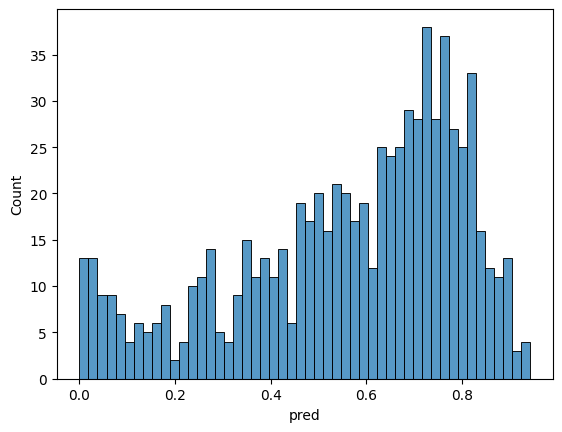

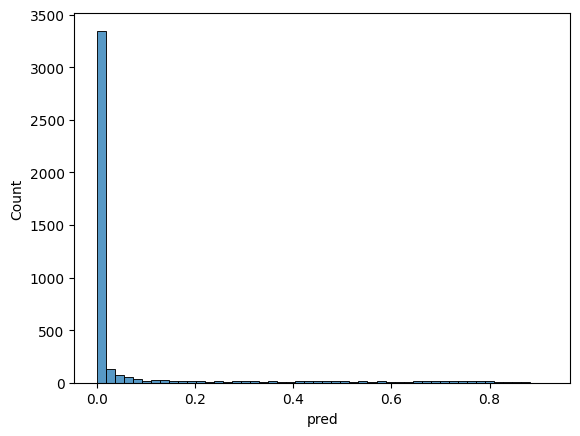

In [181]:
pred = models['XGBClassifier'].predict_proba(X_test)[:, 1]
RESULTS_PRES = pd.DataFrame()
RESULTS_PRES['true'] = y_test
RESULTS_PRES['pred'] = pred
manual_cutpoint = np.argmax(cp_results)/elements
RESULTS_PRES['pred_val'] = (RESULTS_PRES['pred'] >= manual_cutpoint).astype('int')
plt.figure()
sns.histplot(RESULTS_PRES[RESULTS_PRES.true==1], x='pred', bins=50)
plt.figure()
sns.histplot(RESULTS_PRES[RESULTS_PRES.true==0], x='pred', bins=50)

print(classification_report(RESULTS_PRES['true'], RESULTS_PRES['pred_val']))
RESULTS_PRES.set_index(X_test.index, inplace=True)

In [208]:
crstring = classification_report(RESULTS_PRES['true'], RESULTS_PRES['pred_val'])
crstring
from sklearn.metrics import precision_score, recall_score, f1_score

In [211]:
manual_cutpoint

0.253

In [225]:
precision_score_values = [
    precision_score(1-RESULTS_PRES['true'], 1-RESULTS_PRES['pred_val']),
    precision_score(RESULTS_PRES['true'], RESULTS_PRES['pred_val'])
]
recall_score_values = [
    recall_score(1-RESULTS_PRES['true'], 1-RESULTS_PRES['pred_val']),
    recall_score(RESULTS_PRES['true'], RESULTS_PRES['pred_val'])
]

f1_score_values = [
    f1_score(1-RESULTS_PRES['true'], 1-RESULTS_PRES['pred_val']),
    f1_score(RESULTS_PRES['true'], RESULTS_PRES['pred_val'])
]

support_values = [
    (1-RESULTS_PRES['true']).sum(),
    (RESULTS_PRES['true']).sum()
]


model_metrics = pd.DataFrame()
model_metrics['Precision'] = precision_score_values
model_metrics['Recall'] = recall_score_values
model_metrics['F1-score'] = f1_score_values
model_metrics['Support'] = support_values
model_metrics.Support = model_metrics.Support.astype('int')

model_metrics.index.name = 'class'
model_metrics

,Precision,Recall,F1-score,Support
class,,,,
0,0.974719,0.897062,0.934280,4255
1,0.597056,0.867647,0.707357,748


Text(50.722222222222214, 0.5, 'True Value')

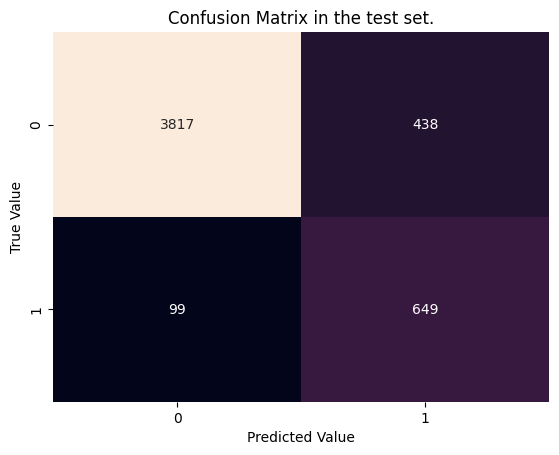

In [190]:
sns.heatmap(
    confusion_matrix(RESULTS_PRES['true'], RESULTS_PRES['pred_val']),
    annot=True,
    fmt='.4g',
    cbar=False
)
plt.title('Confusion Matrix in the test set.')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')

In [182]:
with open('../models/models2/model.pkl', 'wb') as f:
    pickle.dump(models['XGBClassifier'], f)

In [183]:
with open('../models/models2/lb_player_position.pkl', 'wb') as f:
    pickle.dump(lb_player_position, f)

with open('../models/models2/lb_player_position_group.pkl', 'wb') as f:
    pickle.dump(lb_player_position_group, f)

with open('../models/models2/lb_player_position_subgroup.pkl', 'wb') as f:
    pickle.dump(lb_player_position_subgroup, f)

with open('../models/models2/presnap_event_encoder.pkl', 'wb') as f:
    pickle.dump(presnap_event_encoder, f)

with open('../models/models2/pca_model.pkl', 'wb') as f:
    pickle.dump(pca_model, f)

#with open('../models/models2/pca_model2.pkl', 'wb') as f:
#    pickle.dump(pca_model2, f)

#with open('../models/models2/pca_model3.pkl', 'wb') as f:
#    pickle.dump(pca_model3, f)